In [31]:
import pandas as pd

df = pd.read_csv("Online_Retail.csv", on_bad_lines="skip")
df.head(n=5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### 1.2.1 Etape 1 : Nettoyage et preparation des donnees
La premiere etape consiste a preparer le jeu de donnees afin d'assurer sa qualite et sa coherence.
Cette phase comprend notamment :
- le traitement des valeurs manquantes,
- la suppression ou la correction des transactions invalides,
- la conversion des variables temporelles au format approprie,
- la creation de nouvelles variables telles que la depense par transaction et la depense totale par client.

#### 1.2.1.1 le traitement des valeurs manquantes
- conversion les dates en datetime pour pouvoir faire l'imputation correctement
##### Impute missing values
- Numeric: median
- Datetime: median
- Categorical: mode
- CustomerID: "Unknown" 

In [32]:

df_clean = df.copy()

if "InvoiceDate" in df_clean.columns:
    df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"], errors="coerce")

if "CustomerID" in df_clean.columns:
    df_clean["CustomerID"] = df_clean["CustomerID"].fillna("Unknown")

numeric_cols = df_clean.select_dtypes(include=["number"]).columns
if len(numeric_cols) > 0:
    df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())

datetime_cols = df_clean.select_dtypes(include=["datetime64[ns]"]).columns
for col in datetime_cols:
    if df_clean[col].isna().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

categorical_cols = df_clean.select_dtypes(include=["object", "string", "category"]).columns
for col in categorical_cols:
    if col == "CustomerID":
        continue
    if df_clean[col].isna().any():
        mode_value = df_clean[col].mode(dropna=True)
        if not mode_value.empty:
            df_clean[col] = df_clean[col].fillna(mode_value.iloc[0])

#### 1.2.1.2 la suppression ou la correction des transactions invalides

In [33]:
if {"Quantity", "UnitPrice"}.issubset(df_clean.columns):
    df_clean = df_clean[(df_clean["Quantity"] > 0) & (df_clean["UnitPrice"] > 0)]

#### 1.2.1.3 la conversion des variables temporelles au format approprie
#### 1.2.1.4 la creation de nouvelles variables telles que la depense par transaction et la depense totale par client.

In [34]:
if {"Quantity", "UnitPrice"}.issubset(df_clean.columns):
    df_clean["TotalPrice"] = df_clean["Quantity"] * df_clean["UnitPrice"]

if {"CustomerID", "TotalPrice"}.issubset(df_clean.columns):
    customer_spend = df_clean.groupby("CustomerID", as_index=False)["TotalPrice"].sum().rename(columns={"TotalPrice": "TotalSpend"})
(df_clean.head(), customer_spend.head() if "customer_spend" in locals() else None)

(  InvoiceNo StockCode  ...         Country  TotalPrice
 0    536365    85123A  ...  United Kingdom       15.30
 1    536365     71053  ...  United Kingdom       20.34
 2    536365    84406B  ...  United Kingdom       22.00
 3    536365    84029G  ...  United Kingdom       20.34
 4    536365    84029E  ...  United Kingdom       20.34
 
 [5 rows x 9 columns],
   CustomerID  TotalSpend
 0    12346.0    77183.60
 1    12347.0     4310.00
 2    12348.0     1797.24
 3    12349.0     1757.55
 4    12350.0      334.40)

### 1.2.2 Etape 2 : Analyse exploratoire des données
Une analyse exploratoire des données est ensuite réalisée afin de mieux comprendre le comportement des clients et la structure du jeu de données. Cette étape permet notamment :
- d'étudier la distribution des montants dépensés,
- d'identifier les clients les plus actifs,
- d'analyser les achats en fonction des pays et des périodes,
- de mettre en évidence des tendances et des comportements d'achat récurrents

#### 1.2.2.1 Distribution des montants dépensés

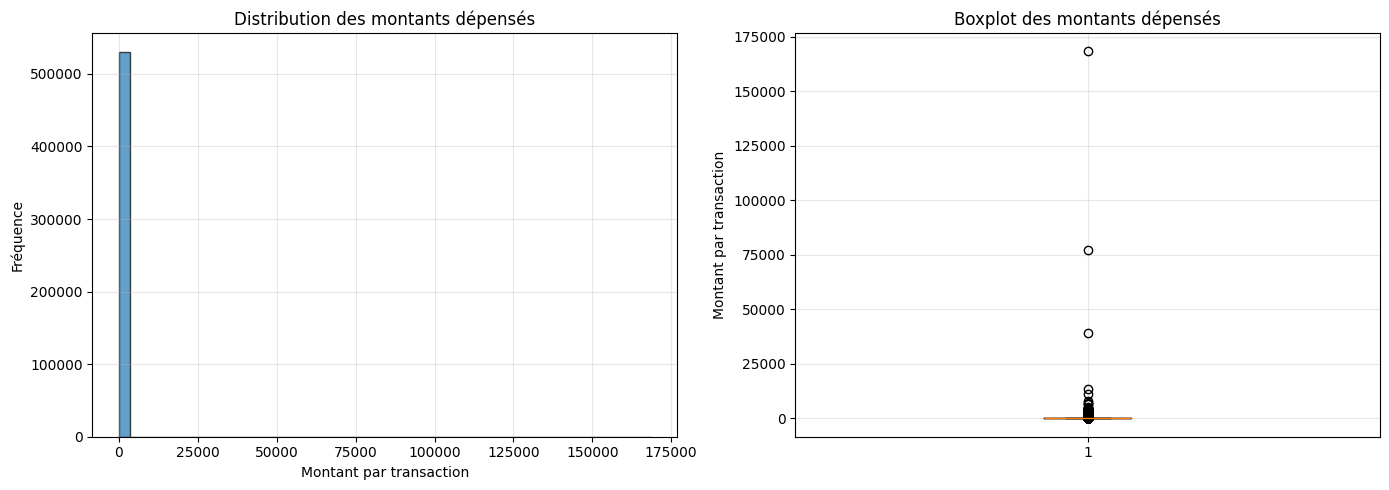

Statistiques des montants dépensés:
  - Moyenne: 20.12
  - Médiane: 9.90
  - Écart-type: 270.36
  - Min: 0.00
  - Max: 168469.60


In [35]:
import matplotlib.pyplot as plt
import numpy as np

if "TotalPrice" in df_clean.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].hist(df_clean["TotalPrice"], bins=50, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel("Montant par transaction")
    axes[0].set_ylabel("Fréquence")
    axes[0].set_title("Distribution des montants dépensés")
    axes[0].grid(True, alpha=0.3)
    
    axes[1].boxplot(df_clean["TotalPrice"], vert=True)
    axes[1].set_ylabel("Montant par transaction")
    axes[1].set_title("Boxplot des montants dépensés")
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Statistiques des montants dépensés:")
    print(f"  - Moyenne: {df_clean['TotalPrice'].mean():.2f}")
    print(f"  - Médiane: {df_clean['TotalPrice'].median():.2f}")
    print(f"  - Écart-type: {df_clean['TotalPrice'].std():.2f}")
    print(f"  - Min: {df_clean['TotalPrice'].min():.2f}")
    print(f"  - Max: {df_clean['TotalPrice'].max():.2f}")

#### 1.2.2.2 Identification des clients les plus actifs

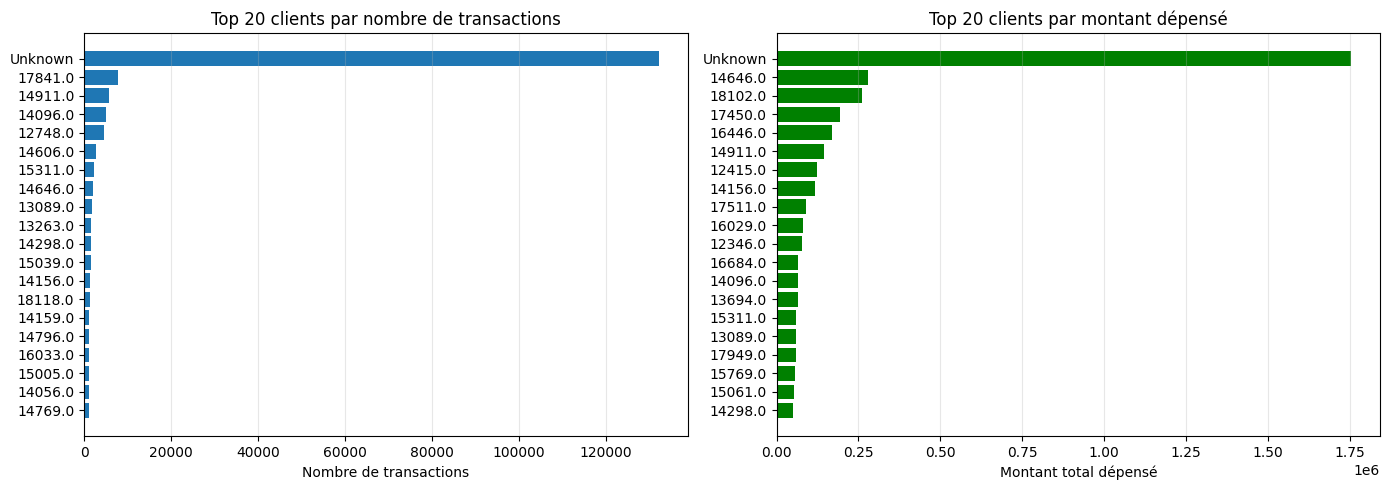

Statistiques des clients:


CustomerID
Unknown    132220
17841.0      7847
14911.0      5675
14096.0      5111
12748.0      4595
14606.0      2700
15311.0      2379
14646.0      2076
13089.0      1818
13263.0      1677
14298.0      1637
15039.0      1502
14156.0      1400
18118.0      1279
14159.0      1204
14796.0      1141
16033.0      1137
15005.0      1119
14056.0      1106
14769.0      1090
dtype: int64

  - Nombre total de clients: 4339
  - Nombre moyen de transactions par client: 122.17


CustomerID
Unknown    1755276.64
14646.0     280206.02
18102.0     259657.30
17450.0     194550.79
16446.0     168472.50
14911.0     143825.06
12415.0     124914.53
14156.0     117379.63
17511.0      91062.38
16029.0      81024.84
12346.0      77183.60
16684.0      66653.56
14096.0      65164.79
13694.0      65039.62
15311.0      60767.90
13089.0      58825.83
17949.0      58510.48
15769.0      56252.72
15061.0      54534.14
14298.0      51527.30
Name: TotalPrice, dtype: float64

  - Dépense moyenne par client: 2458.33
  - Dépense médiane par client: 674.52


In [36]:
if "CustomerID" in df_clean.columns:
    client_transactions = df_clean.groupby("CustomerID").size().sort_values(ascending=False)
    client_spend = df_clean.groupby("CustomerID")["TotalPrice"].sum().sort_values(ascending=False)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].barh(range(20), client_transactions.head(20).values)
    axes[0].set_yticks(range(20))
    axes[0].set_yticklabels(client_transactions.head(20).index)
    axes[0].set_xlabel("Nombre de transactions")
    axes[0].set_title("Top 20 clients par nombre de transactions")
    axes[0].invert_yaxis()
    axes[0].grid(True, alpha=0.3, axis='x')
    
    axes[1].barh(range(20), client_spend.head(20).values, color='green')
    axes[1].set_yticks(range(20))
    axes[1].set_yticklabels(client_spend.head(20).index)
    axes[1].set_xlabel("Montant total dépensé")
    axes[1].set_title("Top 20 clients par montant dépensé")
    axes[1].invert_yaxis()
    axes[1].grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Statistiques des clients:")
    display(client_transactions.head(20))
    print(f"  - Nombre total de clients: {len(client_transactions)}")
    print(f"  - Nombre moyen de transactions par client: {client_transactions.mean():.2f}")
    display(client_spend.head(20))
    print(f"  - Dépense moyenne par client: {client_spend.mean():.2f}")
    print(f"  - Dépense médiane par client: {client_spend.median():.2f}")

#### 1.2.2.3 Analyse des achats par pays et périodes

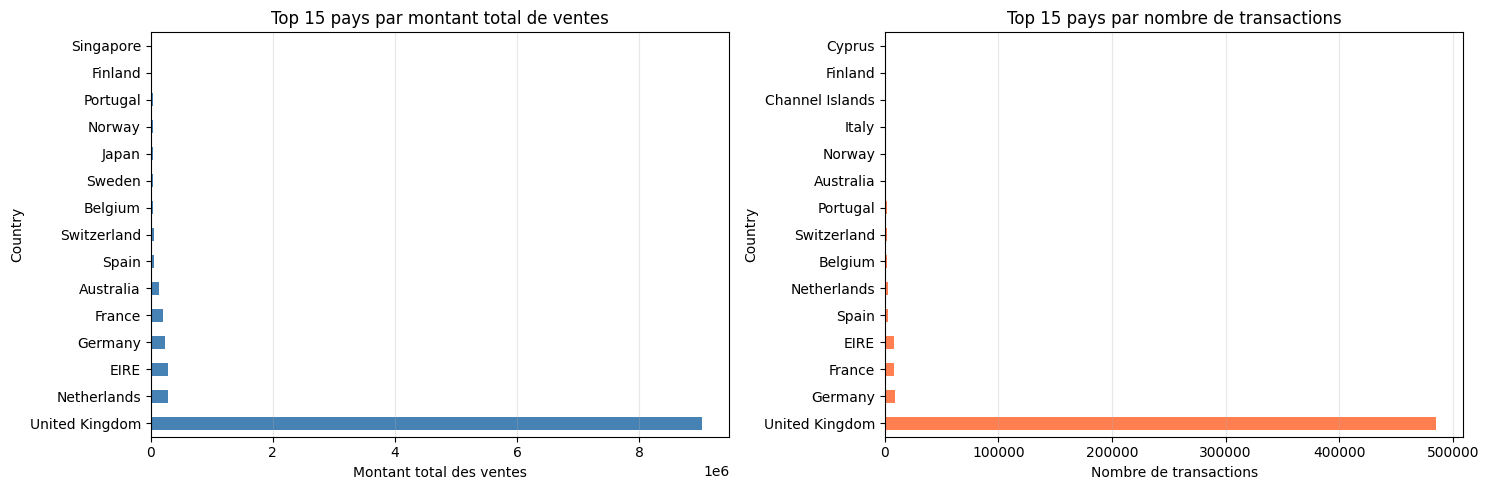

Statistiques par pays:
  - Nombre total de pays: 38


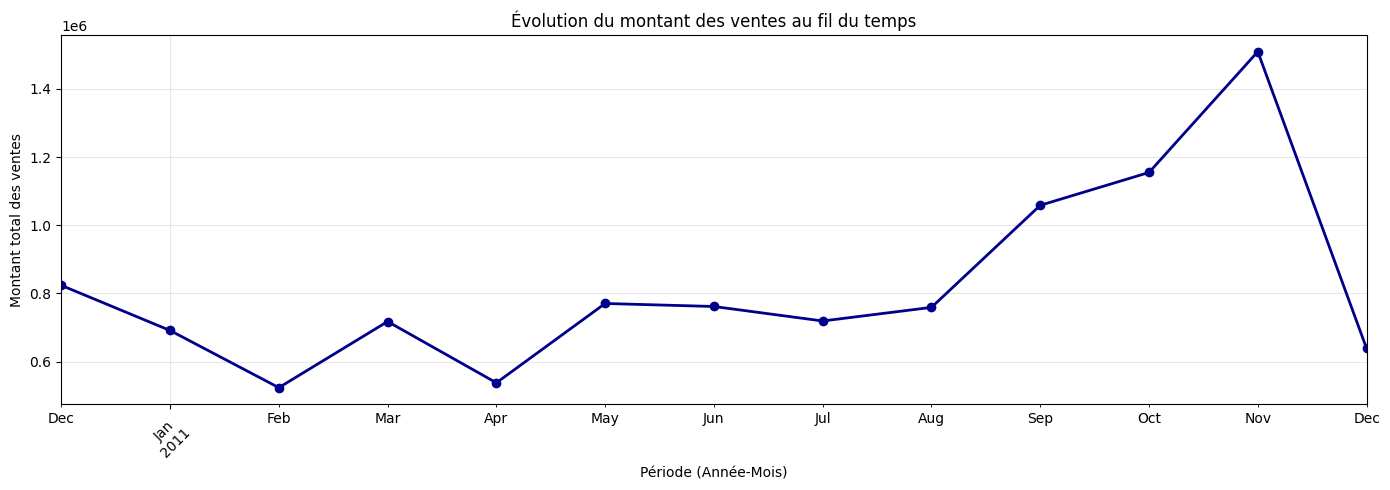

In [37]:
if "Country" in df_clean.columns and "TotalPrice" in df_clean.columns:
    sales_by_country = df_clean.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False)
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    sales_by_country.head(15).plot(kind='barh', ax=axes[0], color='steelblue')
    axes[0].set_xlabel("Montant total des ventes")
    axes[0].set_title("Top 15 pays par montant total de ventes")
    axes[0].grid(True, alpha=0.3, axis='x')
    
    transactions_by_country = df_clean.groupby("Country").size().sort_values(ascending=False)
    transactions_by_country.head(15).plot(kind='barh', ax=axes[1], color='coral')
    axes[1].set_xlabel("Nombre de transactions")
    axes[1].set_title("Top 15 pays par nombre de transactions")
    axes[1].grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Statistiques par pays:")
    print(f"  - Nombre total de pays: {len(sales_by_country)}")

if "InvoiceDate" in df_clean.columns:
    df_clean["YearMonth"] = df_clean["InvoiceDate"].dt.to_period("M")
    sales_by_period = df_clean.groupby("YearMonth")["TotalPrice"].sum()
    
    fig, ax = plt.subplots(figsize=(14, 5))
    sales_by_period.plot(kind='line', ax=ax, marker='o', color='darkblue', linewidth=2)
    ax.set_xlabel("Période (Année-Mois)")
    ax.set_ylabel("Montant total des ventes")
    ax.set_title("Évolution du montant des ventes au fil du temps")
    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

#### 1.2.2.4 Tendances et comportements d'achat récurrents

=== TENDANCES ET COMPORTEMENTS D'ACHAT RÉCURRENTS ===

Top 10 produits par montant total:
                                    Quantity  TotalPrice
Description                                             
DOTCOM POSTAGE                           706   206248.77
REGENCY CAKESTAND 3 TIER               13879   174484.74
PAPER CRAFT , LITTLE BIRDIE            80995   168469.60
WHITE HANGING HEART T-LIGHT HOLDER     37891   106292.77
PARTY BUNTING                          18295    99504.33
JUMBO BAG RED RETROSPOT                48474    94340.05
MEDIUM CERAMIC TOP STORAGE JAR         78033    81700.92
Manual                                  7225    78112.82
POSTAGE                                 3150    78101.88
RABBIT NIGHT LIGHT                     30788    66964.99




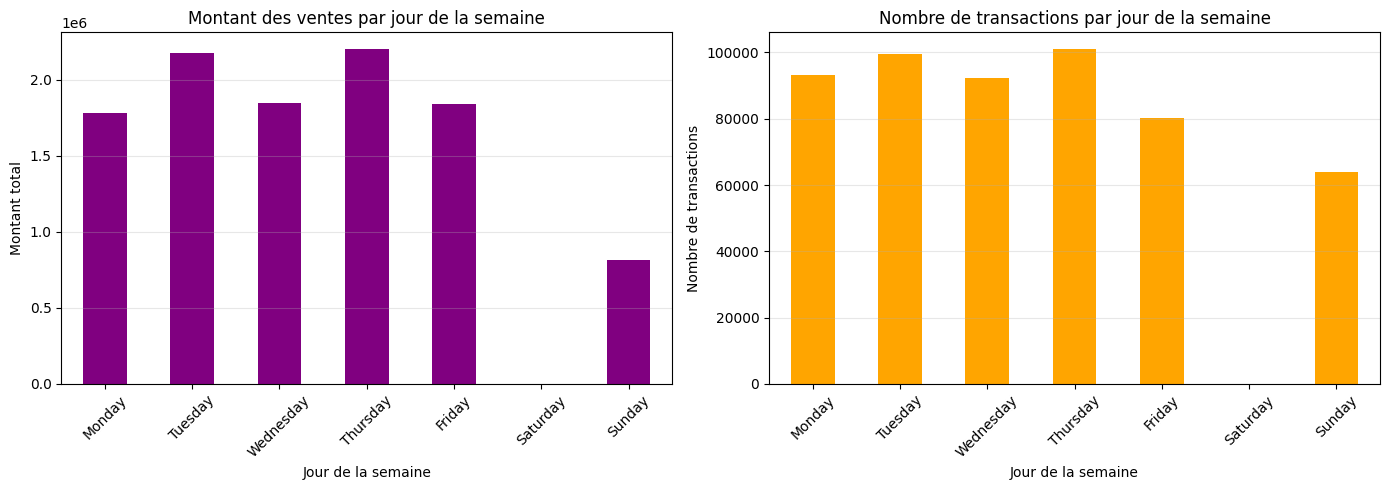

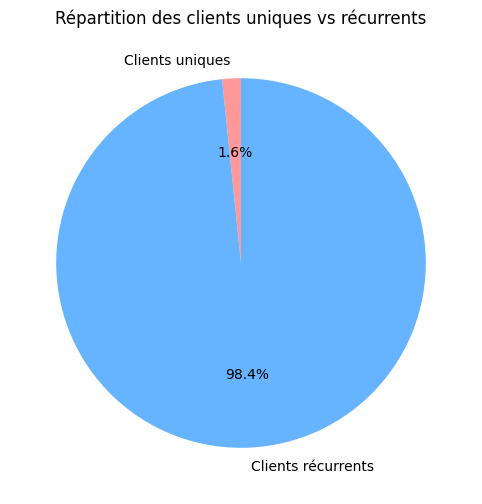


Comportements d'achat:
  - Clients uniques (1 achat): 71 (1.6%)
  - Clients récurrents (>1 achat): 4268 (98.4%)
  - Nombre moyen d'achats par client récurrent: 124.19


In [38]:
print("=== TENDANCES ET COMPORTEMENTS D'ACHAT RÉCURRENTS ===\n")

if "Description" in df_clean.columns:
    top_products = df_clean.groupby("Description").agg({
        "Quantity": "sum",
        "TotalPrice": "sum"
    }).sort_values("TotalPrice", ascending=False)
    
    print("Top 10 produits par montant total:")
    print(top_products.head(10))
    print("\n")

if "InvoiceDate" in df_clean.columns:
    df_clean["DayOfWeek"] = df_clean["InvoiceDate"].dt.day_name()
    daily_sales = df_clean.groupby("DayOfWeek").agg({
        "TotalPrice": ["sum", "count", "mean"]
    })
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    daily_sales_ordered = daily_sales.reindex(day_order, fill_value=0)
    
    daily_sales_ordered["TotalPrice"]["sum"].plot(kind='bar', ax=axes[0], color='purple')
    axes[0].set_xlabel("Jour de la semaine")
    axes[0].set_ylabel("Montant total")
    axes[0].set_title("Montant des ventes par jour de la semaine")
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True, alpha=0.3, axis='y')
    
    daily_sales_ordered["TotalPrice"]["count"].plot(kind='bar', ax=axes[1], color='orange')
    axes[1].set_xlabel("Jour de la semaine")
    axes[1].set_ylabel("Nombre de transactions")
    axes[1].set_title("Nombre de transactions par jour de la semaine")
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

if "CustomerID" in df_clean.columns:
    customer_frequency = df_clean.groupby("CustomerID").size()
    one_time_customers = (customer_frequency == 1).sum()
    repeat_customers = (customer_frequency > 1).sum()
    
    fig, ax = plt.subplots(figsize=(8, 6))
    labels = ['Clients uniques', 'Clients récurrents']
    sizes = [one_time_customers, repeat_customers]
    colors = ['#ff9999', '#66b3ff']
    
    ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
    ax.set_title("Répartition des clients uniques vs récurrents")
    plt.show()
    
    print(f"\nComportements d'achat:")
    print(f"  - Clients uniques (1 achat): {one_time_customers} ({one_time_customers/(one_time_customers+repeat_customers)*100:.1f}%)")
    print(f"  - Clients récurrents (>1 achat): {repeat_customers} ({repeat_customers/(one_time_customers+repeat_customers)*100:.1f}%)")
    print(f"  - Nombre moyen d'achats par client récurrent: {customer_frequency[customer_frequency > 1].mean():.2f}")

### 1.2.3 Etape 3 : Agregation des donnees par client
Les donnees transactionnelles sont agregees pour obtenir une vision globale par client.
Cette etape permet de calculer :
- la depense totale par client,
- le nombre de transactions par client,
- la quantite totale de produits achetes,
- la frequence d'achat (transactions moyennes par mois actif).

In [39]:
if {"CustomerID", "Quantity", "TotalPrice", "InvoiceDate"}.issubset(df_clean.columns):
    ####################################################
    # transactionId InvoiceNo ou nombre de lignes par clients.
    ####################################################
    if {"InvoiceNo"}.issubset(df_clean.columns):
        transactions = df_clean.groupby("CustomerID")["InvoiceNo"].nunique()
    else:
        transactions = df_clean.groupby("CustomerID").size()

    customer_agg = (
        df_clean.groupby("CustomerID")
        .agg(
            totalSpend=("TotalPrice", "sum"),
            totalQuantity=("Quantity", "sum"),
            firstPurchaseDate=("InvoiceDate", "min"),
            lastPurchaseDate=("InvoiceDate", "max"),
        )
        .join(transactions.rename("NumTransactions"))
        .reset_index()
    )

    active_days = (customer_agg["lastPurchaseDate"] - customer_agg["firstPurchaseDate"]).dt.days + 1
    active_days = active_days.clip(lower=1)
    customer_agg["PurchaseFrequency"] = (customer_agg["NumTransactions"] / active_days) * 30
    customer_agg = customer_agg[[
        "CustomerID",
        "totalSpend",
        "NumTransactions",
        "totalQuantity",
        "PurchaseFrequency",
    ]].sort_values("totalSpend", ascending=False)

    print("Agregation des donnees par client:")
    display(customer_agg.head(10))
else:
    print("Erreur Colonnes ou Colonnes manquantes  pour l'agregation")

Agregation des donnees par client:


,CustomerID,totalSpend,NumTransactions,totalQuantity,PurchaseFrequency
4338,Unknown,1755276.64,1428,420564,114.852547
1689,14646.0,280206.02,73,196915,6.186441
4201,18102.0,259657.30,60,64124,4.904632
3728,17450.0,194550.79,46,69993,3.833333
3008,16446.0,168472.50,2,80997,0.292683
1879,14911.0,143825.06,201,80265,16.166220
55,12415.0,124914.53,21,77374,2.006369
1333,14156.0,117379.63,55,57885,4.558011
3771,17511.0,91062.38,31,64549,2.506739
2702,16029.0,81024.84,63,40208,5.625000


### 1.2.4 Etape 4 : Modelisation predictive
A partir des donnees agregees, des mod`eles de prediction sont construits afin d’estimer la
depense des clients. Un modele de base est d’abord mis en place, puis un modele de comparaison
est utilise afin d’evaluer les performances de differentes approches.
Les modeles sont entraınes sur un jeu de donnees d’apprentissage et evalues sur un jeu de test.

In [40]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

X = customer_agg[["NumTransactions", "totalQuantity", "PurchaseFrequency"]]
y = customer_agg["totalSpend"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#linear regression model de base
#random regressor model de comparaison
models = {
    "LinearRegression": Pipeline([
        ("model", LinearRegression()),
    ]),
    "RandomForestRegressor": Pipeline([
        ("model", RandomForestRegressor(n_estimators=100, random_state=42)),   
    ])
}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"{name} - MSE: {mse:.2f}, MAE: {mae:.2f}, R²: {r2:.2f}")

LinearRegression - MSE: 23612132.85, MAE: 2085.68, R²: 0.29
RandomForestRegressor - MSE: 7303619.29, MAE: 597.09, R²: 0.78
